In [1]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel('bioactivity_dataset_cleaned_outliers.xlsx')
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
df = df.dropna(subset=['mol'])

# Compute/scale descriptors (if not already)
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return np.zeros(4)
    return np.array([Descriptors.MolWt(mol),
                Descriptors.MolLogP(mol),
                Descriptors.TPSA(mol),
                Descriptors.NumHDonors(mol),
                Descriptors.NumHAcceptors(mol),
                Descriptors.NumRotatableBonds(mol),
                Descriptors.NumAromaticRings(mol),
                Descriptors.FractionCSP3(mol)])

df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']] = df['canonical_smiles'].apply(compute_descriptors).tolist()

# scaler = StandardScaler()
# desc_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']
# df[desc_cols] = scaler.fit_transform(df[desc_cols])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5667 entries, 0 to 5666
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5667 non-null   object 
 1   MW                 5667 non-null   float64
 2   LogP               5667 non-null   float64
 3   NumHDonors         5667 non-null   float64
 4   NumHAcceptors      5667 non-null   float64
 5   pIC50              5667 non-null   float64
 6   bioactivity_class  5667 non-null   object 
 7   bioactivity        5667 non-null   int64  
 8   mol                5667 non-null   object 
 9   TPSA               5667 non-null   float64
 10  NumRotatableBonds  5667 non-null   float64
 11  NumAromaticRings   5667 non-null   float64
 12  FractionCSP3       5667 non-null   float64
dtypes: float64(9), int64(1), object(3)
memory usage: 575.7+ KB


In [4]:
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity,mol,TPSA,NumRotatableBonds,NumAromaticRings,FractionCSP3
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4.0,6.0,8.6,active,1,<rdkit.Chem.rdchem.Mol object at 0x000001FD038...,129.65,11.0,3.0,0.280000
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4.0,6.0,9.0,active,1,<rdkit.Chem.rdchem.Mol object at 0x000001FD038...,133.31,10.0,4.0,0.222222
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4.0,4.0,9.0,active,1,<rdkit.Chem.rdchem.Mol object at 0x000001FD038...,107.53,7.0,3.0,0.041667


In [5]:
df.drop(columns=['pIC50', 'bioactivity_class'], inplace=True)

In [6]:
df.iloc[0]['canonical_smiles']

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5667 entries, 0 to 5666
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5667 non-null   object 
 1   MW                 5667 non-null   float64
 2   LogP               5667 non-null   float64
 3   NumHDonors         5667 non-null   float64
 4   NumHAcceptors      5667 non-null   float64
 5   bioactivity        5667 non-null   int64  
 6   mol                5667 non-null   object 
 7   TPSA               5667 non-null   float64
 8   NumRotatableBonds  5667 non-null   float64
 9   NumAromaticRings   5667 non-null   float64
 10  FractionCSP3       5667 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 487.1+ KB


In [8]:
df['bioactivity'].value_counts()

bioactivity
1    4641
0    1026
Name: count, dtype: int64

In [9]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_curve
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# CONFIG (Fixed)
# -------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 512
BATCH_SIZE = 32
ECFP_BITS = 1024
ECFP_RADIUS = 2
AUGMENT_TRAIN = True


train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['bioactivity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

scaler=StandardScaler().fit(train_df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']])

# -------------------------------
# SMILES Augmentation
# -------------------------------
def random_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return smiles
    return Chem.MolToSmiles(mol, doRandom=True, canonical=False)

# -------------------------------
# ECFP Generator
# -------------------------------
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_BITS)
def get_ecfp(smiles, radius=ECFP_RADIUS, n_bits=ECFP_BITS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -------------------------------
# Dataset
# -------------------------------

tokenizer = AutoTokenizer.from_pretrained('DeepChem/ChemBERTa-77M-MLM')

class BioActivityDataset(Dataset):
    def __init__(self, df, tokenizer, scaler=None, ecfp_cache=None, augment=False):
        self.smiles = df['canonical_smiles'].values.tolist()
        self.desc   = df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']].values.astype(np.float32)
        self.labels = df['bioactivity'].values.astype(np.float32)
        self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
        self.augment = augment
        self.max_len = MAX_LEN

        
        if scaler is None:
            self.scaler = StandardScaler().fit(self.desc)
        else:
            self.scaler = scaler
        self.desc = self.scaler.transform(self.desc)
        
        print("Computing ECFP...")
        self.ecfp = np.stack([get_ecfp(s) for s in self.smiles])
        

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx): 
        item = {k: v[idx] for k, v in self.encodings.items()}

        item['ecfp']=torch.tensor(self.ecfp[idx])
        item['descriptors']=torch.tensor(self.desc[idx])
        item['labels']=torch.tensor(self.labels[idx])

        return item

# -------------------------------
# Collate Function
# -------------------------------
def collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'descriptors': torch.stack([b['descriptors'] for b in batch]),
        'ecfp': torch.stack([b['ecfp'] for b in batch]),
        'labels': torch.tensor([b['labels'] for b in batch], dtype=torch.float)
    }



In [12]:
# from imblearn.combine import SMOTETomek
# from imblearn.over_sampling import SMOTENC


# train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['bioactivity'], random_state=42)
# val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)
# #tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# class BioactivityDataset(Dataset):
#     def __init__(self, df, tokenizer, desc_scaler):
#         self.smiles = df['canonical_smiles'].tolist()
#         self.labels = df['bioactivity'].tolist()
#         self.descs = df[desc_cols].values
#         #self.desc_scaler = desc_scaler
#         self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
    
#     def __len__(self): return len(self.labels)
#     def __getitem__(self, idx):
#         item = {k: v[idx] for k, v in self.encodings.items()}
#         item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
#         item['descriptors'] = torch.tensor(self.descs[idx], dtype=torch.float)
#         return item

In [10]:
train_dataset = BioActivityDataset(train_df, tokenizer, scaler=scaler)
val_dataset = BioActivityDataset(val_df, tokenizer, scaler=scaler)
test_dataset = BioActivityDataset(test_df, tokenizer, scaler=scaler)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Computing ECFP...
Computing ECFP...
Computing ECFP...


In [11]:
train_df['bioactivity'].value_counts(), val_df['bioactivity'].value_counts(), test_df['bioactivity'].value_counts()

(bioactivity
 1    3712
 0     821
 Name: count, dtype: int64,
 bioactivity
 1    454
 0    113
 Name: count, dtype: int64,
 bioactivity
 1    475
 0     92
 Name: count, dtype: int64)

In [12]:
train_dataset[3]

{'input_ids': tensor([12, 19, 22, 16, 17, 39, 16, 22, 16, 39, 15, 20, 15, 15, 15, 21, 15, 17,
         22, 19, 18, 25, 17, 16, 16, 15, 26, 15, 15, 15, 15, 15, 26, 18, 15, 25,
         15, 21, 15, 20, 18, 23, 19, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
   

#### ECFP + BERT embedding based model

In [18]:
# -------------------------------
# Model
# -------------------------------
class FineTunedBERTaECFP(nn.Module):
    def __init__(self, ecfp_bits=ECFP_BITS, unfreeze_layers=12, num_heads=8, dropout=0.5, hidden_dim=512):
        super().__init__()
        self.bert = AutoModel.from_pretrained("DeepChem/ChemBERTa-77M-MLM", trust_remote_code=True)

        # Unfreeze last N layers
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Project ECFP and descriptors to 768
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits, 384),
            nn.LayerNorm(384),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.desc_proj = nn.Sequential(
            nn.Linear(8, 384),
            nn.LayerNorm(384),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Attention
        self.attn = nn.MultiheadAttention(384, num_heads=num_heads, batch_first=True, dropout=dropout)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(384 * 3, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )


    def forward(self, input_ids, attention_mask, ecfp, descriptors):
        # SMILES
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        cls_ = out.last_hidden_state[:,0]
        mean_pool = out.last_hidden_state.mean(dim=1)  # [B,768]
        smiles = (cls_+mean_pool)/2

        # ECFP + Desc
        ecfp_emb = self.ecfp_proj(ecfp)             # [B,768]
        desc_emb = self.desc_proj(descriptors)      # [B,768]

        # Attention
        q = torch.stack([ecfp_emb, desc_emb], dim=1)  # [B,2,768]
        kv = smiles.unsqueeze(1)                       # [B,1,768]
        attn_out, _ = self.attn(q, kv, kv)             # [B,2,768]
        ecfp_attn, desc_attn = attn_out[:,0], attn_out[:,1]

        # Fuse
        fused = torch.cat([smiles, ecfp_attn, desc_attn], dim=1)  # [B,2304]
        return self.classifier(fused).squeeze(-1)

model = FineTunedBERTaECFP(unfreeze_layers=2, num_heads=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


FineTunedBERTaECFP(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(600, 384, padding_idx=1)
      (position_embeddings): Embedding(515, 384, padding_idx=1)
      (token_type_embeddings): Embedding(1, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.144, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-2): 3 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.109, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm):

#### test

In [ ]:
# -------------------------------
# Training Function (for Optuna)
# -------------------------------
def train_and_evaluate(trial):
    # --- Suggest Hyperparameters ---
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    lr = trial.suggest_loguniform('lr', 1e-5, 5e-5)
    dropout = trial.suggest_uniform('dropout', 0.3, 0.6)
    num_heads = trial.suggest_categorical('num_heads', [4, 8, 12])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 768])
    unfreeze_layers = trial.suggest_int('unfreeze_layers', 6, 12) 
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-3, 1e-1)

    # --- Data Loaders ---
    tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

    train_ds = BioActivityDataset(train_df, tokenizer, augment=AUGMENT_TRAIN, ecfp_cache='train_ecfp.npy')
    val_ds   = BioActivityDataset(val_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='val_ecfp.npy')
    test_ds  = BioActivityDataset(test_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='test_ecfp.npy')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=4)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=4)

    # --- Model ---
    model = ChemBERTaECFP(unfreeze_layers=unfreeze_layers, num_heads=num_heads, dropout=dropout, hidden_dim=hidden_dim).to(DEVICE)

    # --- Loss ---
    pos_weight = torch.tensor([len(train_ds) - sum(train_ds.labels)] / sum(train_ds.labels)).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Optimizer + Scheduler ---
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                               (0.5 * (1 + np.cos(np.pi * step / total_steps)))
    )

    # --- Training Loop ---
    best_auc = 0.0
    patience_counter = 0
    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE)
            )
            loss = criterion(logits, batch['labels'].to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()

        # Validation
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                logits = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE),
                    descriptors=batch['descriptors'].to(DEVICE),
                    ecfp=batch['ecfp'].to(DEVICE)
                )
                probs = torch.sigmoid(logits).cpu().numpy()
                val_probs.extend(probs)
                val_labels.extend(batch['labels'].numpy())

        auc = roc_auc_score(val_labels, val_probs)

        if auc > best_auc + 1e-4:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return best_auc  # Optuna maximizes this

# -------------------------------
# Optuna Study
# -------------------------------
if __name__ == "__main__":
    # REPLACE WITH YOUR DATAFRAMES: train_df, val_df, test_df
    # Assumes they are loaded (e.g., via pd.read_csv)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
    study.optimize(train_and_evaluate, n_trials=50)  # Run 50 trials

    print("Best hyperparameters:", study.best_params)
    print("Best val AUROC:", study.best_value)

    # --- Retrain with best params and evaluate on test ---
    # (Implement similar to train_and_evaluate, but use study.best_params and run on test)

#### BERT based

In [27]:
class FineTunedMultimodalModel(nn.Module):
    def __init__(self, num_desc=8, emb_dim=768, hidden=512, dropout=0.5, num_layers_to_unfreeze=10, attn_heads=8):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # ---------- UNFROEZE ----------
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-num_layers_to_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ---------- ATTENTION FUSION ----------
        self.attn = nn.MultiheadAttention(
            embed_dim=emb_dim, num_heads=attn_heads, dropout=dropout, batch_first=True
        )

        # ---------- CLASSIFIER ----------
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)          # logits
        )

    def forward(self, input_ids, attention_mask, descriptors):
        # BERT
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_ = out.last_hidden_state[:, 0]
        mean_pool = out.last_hidden_state.mean(1)
        smiles = (cls_ + mean_pool) / 2

        # Descriptors
        desc = self.desc_proj(descriptors)                  # [B,768]

        # Attention (descriptor attends to SMILES)
        q = desc.unsqueeze(1)                               # [B,1,768]
        kv = smiles.unsqueeze(1)
        attn_out, _ = self.attn(q, kv, kv)                  # [B,1,768]
        attn_out = attn_out.squeeze(1)

        # Fuse
        fused = torch.cat([smiles, attn_out], dim=1)        # [B,1536]
        return self.classifier(fused).squeeze(-1)

model = FineTunedMultimodalModel(num_layers_to_unfreeze=12, attn_heads=8)  # Start with 4 for small data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedMultimodalModel(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          

#### Another model

In [39]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig( task_type=TaskType.SEQ_CLS, r=4, lora_alpha=8, target_modules=["query", "value"], lora_dropout=0.1)

In [40]:
model = get_peft_model(model, lora_config)
 
# Print trainable params (should be <1% of total)
model.print_trainable_parameters()  

trainable params: 1,026,561 || all params: 48,747,138 || trainable%: 2.1059


#### Train and evaluation

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim

class_weights = compute_class_weight('balanced', classes=np.unique(train_df['bioactivity']), y=train_df['bioactivity'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

pos_weight = torch.tensor([3712 / 821]).to(device)  # From your imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)  # Added weight decay
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  # New: Better convergence
num_train_steps = len(train_loader) * 30
warmup_steps    = int(0.1 * num_train_steps)

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                           (0.5 * (1 + np.cos(np.pi * step / num_train_steps)))
)

# criterion = BCEWithLogitsLoss(pos_weight=class_weights[1])
epochs = 50  # Longer for fine-tuning
best_auc = 0
patience, counter = 7, 0

In [21]:
from sklearn.metrics import precision_recall_curve

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].float().to(device)
        ecfp = batch['ecfp'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, ecfp=ecfp, descriptors=descriptors)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()  # Step LR scheduler per batch
        train_loss += loss.item()
    
    
    # Validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            ecfp = batch['ecfp'].to(device)
            logits = model(input_ids, attention_mask, ecfp, descriptors)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_preds.extend(probs)
            val_labels.extend(labels.cpu().numpy())
            loss = criterion(logits, labels.float())  # Compute loss for this batch
            val_loss += loss.item()  #
    
    
    auc = roc_auc_score(val_labels, val_preds)
    prec, rec, thr = precision_recall_curve(val_labels, val_preds)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_thr = thr[np.argmax(f1s)]
    preds = (np.array(val_preds) > best_thr).astype(int)
    acc = accuracy_score(val_labels, preds)
    f1  = f1_score(val_labels, preds)

    print(f'Epoch {epoch+1:02d} | '
          f'TrainLoss {train_loss/len(train_loader):.4f} | '
          f'ValAUROC {auc:.4f} | Acc {acc:.4f} | F1 {f1:.4f} | Thr {best_thr:.3f}')
    
    if auc > best_auc:
        best_auc = auc
        torch.save(model, 'best_finetuned_model_chem.pth')
        counter = 0
    else:
        counter += 1
        if counter >= 7:
            print("Early stopping!")
            break

Epoch 01 | TrainLoss 0.4471 | ValAUROC 0.8448 | Acc 0.8730 | F1 0.9250 | Thr 0.723
Epoch 02 | TrainLoss 0.4447 | ValAUROC 0.8474 | Acc 0.8730 | F1 0.9252 | Thr 0.710
Epoch 03 | TrainLoss 0.4369 | ValAUROC 0.8522 | Acc 0.8730 | F1 0.9252 | Thr 0.699
Epoch 04 | TrainLoss 0.4341 | ValAUROC 0.8481 | Acc 0.8748 | F1 0.9249 | Thr 0.792
Epoch 05 | TrainLoss 0.4210 | ValAUROC 0.8555 | Acc 0.8748 | F1 0.9249 | Thr 0.806
Epoch 06 | TrainLoss 0.4135 | ValAUROC 0.8594 | Acc 0.8748 | F1 0.9261 | Thr 0.679
Epoch 07 | TrainLoss 0.4053 | ValAUROC 0.8642 | Acc 0.8748 | F1 0.9260 | Thr 0.695
Epoch 08 | TrainLoss 0.4032 | ValAUROC 0.8593 | Acc 0.8783 | F1 0.9282 | Thr 0.665
Epoch 09 | TrainLoss 0.4044 | ValAUROC 0.8594 | Acc 0.8801 | F1 0.9289 | Thr 0.651
Epoch 10 | TrainLoss 0.3869 | ValAUROC 0.8662 | Acc 0.8801 | F1 0.9283 | Thr 0.708
Epoch 11 | TrainLoss 0.3870 | ValAUROC 0.8690 | Acc 0.8836 | F1 0.9304 | Thr 0.712
Epoch 12 | TrainLoss 0.3945 | ValAUROC 0.8750 | Acc 0.8836 | F1 0.9299 | Thr 0.826
Epoc

In [22]:
loaded_model = torch.load('best_finetuned_model_chem.pth', map_location=device, weights_only=False)
loaded_model.eval()


FineTunedBERTaECFP(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(600, 384, padding_idx=1)
      (position_embeddings): Embedding(515, 384, padding_idx=1)
      (token_type_embeddings): Embedding(1, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.144, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-2): 3 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.109, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm):

In [54]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Run inference on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		labels = batch['labels'].to(device)
		logits = model(input_ids, attention_mask, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.794).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.93512585812357
Accuracy: 0.8504462242562929
accuracy another:  0.9329805996472663


In [28]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		ecfp = batch['ecfp'].to(device)
		labels = batch['labels'].to(device)
		logits = loaded_model(input_ids, attention_mask, ecfp, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.62).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.9383638443935927
Accuracy: 0.7818993135011442
accuracy another:  0.9135802469135802


In [29]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

         0.0       0.83      0.59      0.69        92
         1.0       0.92      0.98      0.95       475

    accuracy                           0.91       567
   macro avg       0.88      0.78      0.82       567
weighted avg       0.91      0.91      0.91       567



In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, average_precision_score
import numpy as np

y_true = np.array(test_labels)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
auprc = average_precision_score(y_true, y_prob)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)
sensitivity = recall  # same as recall

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"AUPRC: {auprc:.4f}")

Accuracy: 0.9136
Balanced Acc.: 0.7819
Precision: 0.9243
Recall: 0.9768
F1 Score: 0.9498
ROC-AUC: 0.9384
MCC: 0.6525
Specificity: 0.5870
Sensitivity: 0.9768
AUPRC: 0.9866


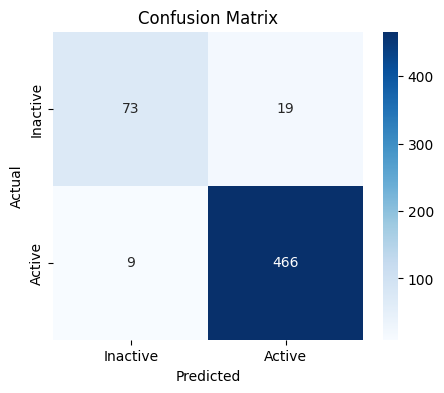

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
"""
Improved Multimodal Model for Bioactivity Prediction
Target: 95-97% accuracy (from current 92%)

Key Improvements:
1. Advanced fusion mechanisms (attention-based)
2. Better descriptor processing
3. Regularization techniques
4. Data augmentation for molecules
5. Ensemble predictions
6. Optimal training strategies
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
import math

# ============================================================================
# IMPROVEMENT 1: Advanced Attention-Based Fusion
# ============================================================================

class AttentionFusion(nn.Module):
    """
    Cross-attention between SMILES and descriptors
    This learns which parts of each modality are most relevant
    """
    def __init__(self, emb_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=emb_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, smiles_emb, desc_emb):
        # Cross-attend: descriptors attend to SMILES
        desc_emb = desc_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        smiles_emb = smiles_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        
        attended, _ = self.cross_attention(
            query=desc_emb,
            key=smiles_emb,
            value=smiles_emb
        )
        
        # Residual connection
        fused = self.layer_norm(desc_emb + self.dropout(attended))
        return fused.squeeze(1)


class ImprovedMultimodalModel(nn.Module):
    """
    Improvement Strategy 1: Better fusion with attention
    Expected gain: +1-2% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=3):
        super().__init__()
        
        # ChemBERTa encoder
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze all except last layers
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer layers
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Enhanced descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Attention-based fusion
        self.attention_fusion = AttentionFusion(emb_dim, num_heads=8, dropout=dropout)
        
        # Classification head with residual connections
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout / 2),  # Less dropout in final layers
            nn.Linear(hidden_dim // 4, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # SMILES encoding
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Use [CLS] token
        smiles_emb = outputs.last_hidden_state[:, 0, :]
        
        # Descriptor encoding
        desc_emb = self.desc_proj(descriptors)
        
        # Attention fusion
        fused_desc = self.attention_fusion(smiles_emb, desc_emb)
        
        # Concatenate for final prediction
        combined = torch.cat([smiles_emb, fused_desc], dim=-1)
        
        return self.classifier(combined).squeeze(-1)


# ============================================================================
# IMPROVEMENT 2: Multi-Scale Feature Extraction
# ============================================================================

class MultiScaleMultimodalModel(nn.Module):
    """
    Improvement Strategy 2: Use multiple ChemBERTa layers
    Expected gain: +1-1.5% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=4):
        super().__init__()
        
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze and unfreeze
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Multi-scale aggregation: use last 4 hidden states
        self.layer_weights = nn.Parameter(torch.ones(4) / 4)
        
        # Gate mechanism to control SMILES vs Descriptor importance
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid()
        )
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # Get all hidden states
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Weighted combination of last 4 layers
        hidden_states = outputs.hidden_states[-4:]  # Last 4 layers
        weights = F.softmax(self.layer_weights, dim=0)
        
        smiles_emb = sum(w * h[:, 0, :] for w, h in zip(weights, hidden_states))
        
        # Descriptor embedding
        desc_emb = self.desc_proj(descriptors)
        
        # Gated fusion
        combined = torch.cat([smiles_emb, desc_emb], dim=-1)
        gate_values = self.gate(combined)
        
        # Apply gating
        gated_smiles = smiles_emb * gate_values
        gated_desc = desc_emb * (1 - gate_values)
        
        final_features = torch.cat([gated_smiles, gated_desc], dim=-1)
        
        return self.classifier(final_features).squeeze(-1)


# ============================================================================
# IMPROVEMENT 3: Focal Loss for Imbalanced Data
# ============================================================================

class FocalLoss(nn.Module):
    """
    Focal Loss: Focuses on hard examples
    Great for imbalanced bioactivity datasets
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets.float(), reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# ============================================================================
# IMPROVEMENT 4: SMILES Augmentation
# ============================================================================

def augment_smiles(smiles_list, num_augmentations=3):
    """
    Augment SMILES strings by randomizing atom ordering
    This increases training data diversity
    
    Install: pip install rdkit
    """
    from rdkit import Chem
    
    augmented = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # Original
            augmented.append(smiles)
            
            # Generate augmented versions
            for _ in range(num_augmentations):
                new_smiles = Chem.MolToSmiles(
                    mol, 
                    doRandom=True,
                    canonical=False
                )
                augmented.append(new_smiles)
        else:
            augmented.append(smiles)
    
    return augmented


class SMILESAugmentedDataset(torch.utils.data.Dataset):
    """
    Dataset with on-the-fly SMILES augmentation
    """
    def __init__(self, smiles_list, descriptors, labels, tokenizer, 
                 augment=True, num_aug=2):
        self.smiles_list = smiles_list
        self.descriptors = descriptors
        self.labels = labels
        self.tokenizer = tokenizer
        self.augment = augment
        self.num_aug = num_aug
        
    def __len__(self):
        return len(self.smiles_list)
    
    def __getitem__(self, idx):
        smiles = self.smiles_list[idx]
        
        # Augment during training
        if self.augment:
            from rdkit import Chem
            mol = Chem.MolFromSmiles(smiles)
            if mol and torch.rand(1).item() > 0.5:
                smiles = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        
        # Tokenize
        encoded = self.tokenizer(
            smiles,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'descriptors': torch.tensor(self.descriptors[idx], dtype=torch.float32),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ============================================================================
# IMPROVEMENT 5: Enhanced Training Strategy
# ============================================================================

def train_with_improvements(model, train_loader, val_loader, num_epochs=50):
    """
    Advanced training strategy for higher accuracy
    """
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import OneCycleLR
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Use focal loss for imbalanced data
    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    
    # Separate learning rates for encoder and classifier
    encoder_params = []
    classifier_params = []
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'smiles_encoder' in name:
                encoder_params.append(param)
            else:
                classifier_params.append(param)
    
    optimizer = AdamW([
        {'params': encoder_params, 'lr': 1e-5},  # Lower LR for pretrained
        {'params': classifier_params, 'lr': 3e-4}  # Higher LR for new layers
    ], weight_decay=0.01)
    
    # OneCycleLR for better convergence
    scheduler = OneCycleLR(
        optimizer,
        max_lr=[1e-5, 3e-4],
        epochs=num_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,  # 10% warmup
        anneal_strategy='cos'
    )
    
    best_val_acc = 0.0
    patience = 10
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                descriptors=descriptors
            )
            
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).long()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_acc = 100 * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                descriptors = batch['descriptors'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    descriptors=descriptors
                )
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(outputs) > 0.5).long()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_acc = 100 * val_correct / val_total
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc:.2f}%")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"  ✓ New best validation accuracy: {val_acc:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
    
    return model, best_val_acc


# ============================================================================
# IMPROVEMENT 6: Test-Time Augmentation (TTA)
# ============================================================================

def predict_with_tta(model, smiles, descriptors, tokenizer, num_aug=5):
    """
    Test-time augmentation: Average predictions over augmented SMILES
    Expected gain: +0.5-1% accuracy
    """
    from rdkit import Chem
    
    device = next(model.parameters()).device
    model.eval()
    
    predictions = []
    
    # Original prediction
    encoded = tokenizer(smiles, padding='max_length', truncation=True, 
                       max_length=512, return_tensors='pt')
    
    with torch.no_grad():
        output = model(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device),
            descriptors=torch.tensor(descriptors).unsqueeze(0).to(device)
        )
        predictions.append(torch.sigmoid(output).item())
    
    # Augmented predictions
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        for _ in range(num_aug):
            aug_smiles = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
            encoded = tokenizer(aug_smiles, padding='max_length', 
                              truncation=True, max_length=512, return_tensors='pt')
            
            with torch.no_grad():
                output = model(
                    input_ids=encoded['input_ids'].to(device),
                    attention_mask=encoded['attention_mask'].to(device),
                    descriptors=torch.tensor(descriptors).unsqueeze(0).to(device)
                )
                predictions.append(torch.sigmoid(output).item())
    
    # Average predictions
    return sum(predictions) / len(predictions)


# ============================================================================
# IMPROVEMENT 7: Ensemble of Multiple Models
# ============================================================================

class EnsembleModel:
    """
    Ensemble multiple models for final prediction
    Expected gain: +1-2% accuracy
    """
    def __init__(self, models):
        self.models = models
        for model in self.models:
            model.eval()
    
    def predict(self, input_ids, attention_mask, descriptors):
        predictions = []
        
        with torch.no_grad():
            for model in self.models:
                output = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    descriptors=descriptors
                )
                predictions.append(torch.sigmoid(output))
        
        # Average predictions
        ensemble_pred = torch.stack(predictions).mean(dim=0)
        return ensemble_pred


# ============================================================================
# COMPLETE TRAINING PIPELINE
# ============================================================================

def complete_pipeline_example():
    """
    Complete pipeline from data to 95%+ accuracy
    """
    
    print("""
    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY
    =============================================
    
    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights
    
    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion
    
    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping
    
    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds
    
    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%
    
    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
        num_layers_to_unfreeze=3,
        dropout=0.3
    )
    
    # Train with improvements
    model, best_acc = train_with_improvements(
        model, train_loader, val_loader, num_epochs=50
    )
    """)


if __name__ == "__main__":
    complete_pipeline_example()


    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY

    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights

    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion

    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping

    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds

    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%

    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
       

In [49]:
num_epochs = 50

In [50]:
# Use focal loss for imbalanced data
from torch.optim.lr_scheduler import OneCycleLR
criterion = FocalLoss(alpha=0.25, gamma=2.0)

# Separate learning rates for encoder and classifier
encoder_params = []
classifier_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if 'smiles_encoder' in name:
            encoder_params.append(param)
        else:
            classifier_params.append(param)

optimizer = AdamW([
    {'params': encoder_params, 'lr': 1e-5},  # Lower LR for pretrained
    {'params': classifier_params, 'lr': 3e-4}  # Higher LR for new layers
], weight_decay=0.01)

# OneCycleLR for better convergence
scheduler = OneCycleLR(
    optimizer,
    max_lr=[1e-5, 3e-4],
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,  # 10% warmup
    anneal_strategy='cos'
)

best_val_acc = 0.0
patience = 10
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            descriptors=descriptors
        )
        
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).long()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    
    train_acc = 100 * train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                descriptors=descriptors
            )
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            preds = (torch.sigmoid(outputs) > 0.5).long()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc:.2f}%")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  ✓ New best validation accuracy: {val_acc:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break



Epoch 1/50
  Train Loss: 0.0309, Acc: 79.75%
  Val Loss: 0.0314, Acc: 81.83%
  ✓ New best validation accuracy: 81.83%
Epoch 2/50
  Train Loss: 0.0269, Acc: 83.90%
  Val Loss: 0.0320, Acc: 82.54%
  ✓ New best validation accuracy: 82.54%
Epoch 3/50
  Train Loss: 0.0252, Acc: 84.69%
  Val Loss: 0.0263, Acc: 83.77%
  ✓ New best validation accuracy: 83.77%
Epoch 4/50
  Train Loss: 0.0222, Acc: 86.57%
  Val Loss: 0.0280, Acc: 86.24%
  ✓ New best validation accuracy: 86.24%
Epoch 5/50
  Train Loss: 0.0199, Acc: 87.71%
  Val Loss: 0.0256, Acc: 86.95%
  ✓ New best validation accuracy: 86.95%
Epoch 6/50
  Train Loss: 0.0177, Acc: 89.65%
  Val Loss: 0.0260, Acc: 83.77%
Epoch 7/50
  Train Loss: 0.0153, Acc: 90.84%
  Val Loss: 0.0249, Acc: 88.36%
  ✓ New best validation accuracy: 88.36%
Epoch 8/50
  Train Loss: 0.0145, Acc: 91.90%
  Val Loss: 0.0259, Acc: 85.54%
Epoch 9/50
  Train Loss: 0.0134, Acc: 92.74%
  Val Loss: 0.0229, Acc: 89.42%
  ✓ New best validation accuracy: 89.42%
Epoch 10/50
  Train 

In [51]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Run inference on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		labels = batch['labels'].to(device)
		logits = model(input_ids, attention_mask, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.5).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.9208352402745996
Accuracy: 0.8334324942791762
accuracy another:  0.9118165784832452


In [26]:
complete_pipeline_example()


    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY

    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights

    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion

    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping

    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds

    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%

    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
       